# Análisis de operaciones: habitaciones, baños y camas frente a la ocupación por ciudad

**Pregunta de negocio:** ¿cómo afecta el número de habitaciones,
baños y camas disponibles a la disponibilidad media de los
alojamientos? ¿Difiere entre ciudades?

**Nota sobre la métrica:** el análisis se trabaja en términos de
**ocupación** (días ocupados) y no de disponibilidad (días libres),
porque la variable dependiente de una regresión lineal debe ser
numérica y continua, y la ocupación es la forma más directa de
expresarla. Ambas son equivalentes en sentido inverso: más ocupación
significa, automáticamente, menos disponibilidad
(`disponibilidad = 365 − ocupación`). Toda conclusión sobre
ocupación se puede leer también en términos de disponibilidad sin
más que invertir el signo.

Este notebook realiza el proceso completo necesario para responder a
la pregunta de negocio:

1. Carga de datos y verificación de las variables de ocupación ya
   transformadas (4 plazos disponibles).
2. Exploración inicial de los datos (EDA), con interpretación
   detallada de cada gráfico.
3. Revisión de multicolinealidad entre variables explicativas (VIF).
4. Evaluación de si conviene aplicar una reducción de datos adicional.
5. Modelo de regresión lineal múltiple y verificación de sus
   supuestos.
6. Modelo con interacción ciudad × variable estructural, para
   comprobar si el efecto difiere entre ciudades.
7. Comprobación de robustez del modelo en los distintos plazos.
8. Propuestas de visualización para la presentación en Canva.

**Puntos clave del enfoque:**
- Se trabaja con la **ocupación en días** (no en porcentaje), porque
  la variable dependiente de una regresión lineal debe ser numérica
  y continua.
- Se revisa con cuidado la posible **multicolinealidad** entre
  `bedrooms`, `bathrooms` y `beds`, antes de dar por buenos los
  coeficientes del modelo.

El análisis avanza **de lo general a lo particular**: primero una
foto agregada de la ocupación por ciudad, después el efecto conjunto
de habitaciones, baños y camas sobre la ocupación, y por último si
ese efecto difiere entre ciudades.


## 1. Librerías

Instalamos `statsmodels`, ya que no viene incluida por defecto en
todos los entornos y la necesitamos para el modelo de regresión y
para el cálculo del VIF.

In [1]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Importamos el resto de librerías que se usarán a lo largo del
notebook:

- `pandas` y `numpy`: carga y manipulación de datos.
- `matplotlib` y `seaborn`: gráficos.
- `statsmodels`: modelo de regresión, VIF y test de normalidad.
- `patsy`: construcción de la matriz de diseño (variables dummy)
  para el cálculo del VIF.
- `pathlib`: resolución de rutas de forma independiente del sistema
  operativo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.tools import add_constant
from patsy import dmatrix
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carga de datos y preparación

Partimos del dataset **ya limpio y transformado**
(`clean_dataset_13_07_2026.csv`), que llega desde las fases previas
de Data Cleaning y Data Transformation. Esto significa que las
columnas de ocupación (`occupancy_30/60/90/365`) **ya vienen
calculadas** en el propio archivo; en la sección 2.1 simplemente se
verifica que existen y se recalculan como comprobación, sin que esto
cambie los valores.

La función `encontrar_raiz_proyecto()` sube por los directorios
padre hasta encontrar la carpeta raíz del repositorio (`Equip_34`),
para que la ruta funcione igual sin importar desde qué carpeta se
abra el notebook (evita errores de ruta relativa al abrir el
notebook desde fuera de `Scripts/`).

**Nota:** este notebook ya refleja la actualización del dataset del
13/07 (9.650 filas, frente a las 7.693 de la versión anterior). Todos
los resultados de este notebook están recalculados sobre esta
versión.


In [3]:
def encontrar_raiz_proyecto(nombre_carpeta='Equip_34'):
    '''
    Sube desde el directorio actual hasta encontrar la carpeta
    raíz del proyecto.
    '''
    actual = Path.cwd()
    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta
    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}"
    )

raiz_proyecto = encontrar_raiz_proyecto('Equip_34')
ruta = raiz_proyecto / 'Data' / 'clean_dataset_13_07_2026.csv'

print(f"Ruta resuelta: {ruta}")
df = pd.read_csv(ruta)
print(df.shape)
df.head()

Ruta resuelta: c:\Users\giorg\Desktop\ProjecteData\Equip_34\Data\clean_dataset_13_07_2026.csv
(9507, 54)


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,occupancy_rate_365,is_instant_bookable_numeric,cat_premium,cat_confort,cat_conectividad,cat_familia,cat_seguridad,cat_parking,cat_cocina,logp
0,9701470,"BORRELL, 4 bedrooms apt in Sant Antoni, Eixample","The apartment is really nice, comfortable, qui...",1310304,Sant Antoni,Eixample,Entire home/apt,6,2.0,4.0,...,8.77,0,0,1,1,1,0,0,1,7.064759
1,13311614,quiet single room&private bathroom near pza Es...,"family owned flat of 120 m2. , we live in the...",55899782,la Nova Esquerra de l'Eixample,Eixample,Private room,1,1.0,1.0,...,100.00,0,0,1,1,0,0,0,1,5.857933
2,7003233,Cozy flat near Sagrada Familia,"Flat with two doble rooms. Aircon, wifi and pa...",8693964,el Clot,Sant Mart�,Entire home/apt,4,1.0,2.0,...,75.89,0,0,1,1,1,0,0,1,7.090077
3,15713525,Nice room in classic eixample flat with balcony,"Lugares de inter�s: Cervecer�a Catalana, Casa ...",3297768,l'Antiga Esquerra de l'Eixample,Eixample,Private room,1,2.0,1.0,...,90.41,1,0,1,1,1,1,0,1,5.521461
4,13567392,"Double Room w. Balcony/Priv Bathroom, Raval Ce...",Located in the Heart of Raval and in front of ...,4092770,el Raval,Ciutat Vella,Private room,2,2.0,1.0,...,44.11,0,0,1,1,1,1,0,1,6.214608


### 2.1 Variables de ocupación (verificación)

El dataset ya trae calculadas las columnas de ocupación para los
cuatro plazos disponibles (30, 60, 90 y 365 días), a partir de la
disponibilidad (`availability_30/60/90/365`). Se vuelven a calcular
aquí como comprobación de que la lógica es la misma que se usó en
Data Transformation (días ocupados = total del plazo − días
disponibles); si los valores ya existentes fueran correctos, esta
celda no debería cambiar nada.

In [4]:
# comprobamos/recalculamos la ocupación para los 4 plazos disponibles: 30, 60, 90 y 365 días
plazos = {'30': 30, '60': 60, '90': 90, '365': 365}

for suf, total in plazos.items():
    df[f'occupancy_{suf}'] = total - df[f'availability_{suf}']
    df[f'occupancy_rate_{suf}'] = (df[f'occupancy_{suf}'] / total * 100).round(2)

# muestra de las columnas de ocupación
df[[f'occupancy_{suf}' for suf in plazos.keys()] + [f'occupancy_rate_{suf}' for suf in plazos.keys()]].head()

,occupancy_30,occupancy_60,occupancy_90,occupancy_365,occupancy_rate_30,occupancy_rate_60,occupancy_rate_90,occupancy_rate_365
0,28,32,32,32,93.33,53.33,35.56,8.77
1,30,60,90,365,100.00,100.00,100.00,100.00
2,2,2,2,277,6.67,3.33,2.22,75.89
3,30,55,55,330,100.00,91.67,61.11,90.41
4,25,55,85,161,83.33,91.67,94.44,44.11


## 3. Selección de variables para el modelo

### Variables utilizadas en la regresión

| Rol | Variable | Descripción |
|---|---|---|
| Dependiente | `occupancy_30` | Días ocupados en los últimos 30 días |
| Dependiente | `occupancy_60` | Días ocupados en los últimos 60 días |
| Dependiente | `occupancy_90` | Días ocupados en los últimos 90 días |
| Dependiente | `occupancy_365` | Días ocupados en el último año |
| Interés | `bedrooms` | Número de habitaciones |
| Interés | `bathrooms` | Número de baños |
| Interés | `beds` | Número de camas |
| Control | `city` | Ciudad donde se ubica el alojamiento |

Se trabaja sobre una copia del dataframe reducida a estas variables. Para cada uno de los cuatro modelos de regresión (30, 60, 90 y 365 días), se eliminan únicamente los registros que presentan valores nulos en las variables necesarias para el ajuste, ya que la regresión lineal no admite observaciones con valores faltantes en las variables incluidas en el modelo.

In [5]:
columnas_modelo = [
    'occupancy_365', 'occupancy_90', 'occupancy_60', 'occupancy_30', 'city', 'bathrooms',
    'bedrooms', 'beds'
]

df_modelo = df[columnas_modelo].copy()

print("Registros antes de eliminar nulos:", df_modelo.shape[0])
nulos = df_modelo.isna().sum()
print(nulos[nulos > 0])

df_modelo = df_modelo.dropna()
print("Registros tras eliminar nulos:", df_modelo.shape[0])

Registros antes de eliminar nulos: 9507
bathrooms    71
bedrooms     69
beds         45
dtype: int64
Registros tras eliminar nulos: 9330


## 4. Análisis exploratorio (EDA)

Empezamos con un resumen estadístico de las variables numéricas del modelo.

In [6]:
# ESTADÍSTICOS DESCRIPTIVOS
# Resumen de las variables numéricas utilizadas en el modelo
df_modelo[
    [  'bathrooms',
    'bedrooms', 'beds',
    'occupancy_30','occupancy_60','occupancy_90','occupancy_365'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
bathrooms,9330.0,1.599250,0.994496,0.0,1.0,1.0,2.0,13.0
bedrooms,9330.0,1.943516,1.381207,0.0,1.0,2.0,3.0,50.0
beds,9330.0,2.936120,2.276378,0.0,1.0,2.0,4.0,30.0
occupancy_30,9330.0,16.957985,11.840290,0.0,4.0,19.0,30.0,30.0
occupancy_60,9330.0,31.210075,22.982533,0.0,7.0,31.0,58.0,60.0
occupancy_90,9330.0,43.856056,33.747404,0.0,10.0,41.0,80.0,90.0
occupancy_365,9330.0,176.853162,130.623834,0.0,47.0,182.0,298.0,365.0


**Comentario:** Se observa que la mayoría de los alojamientos dispone de entre 1 y 3 habitaciones, 1 o 2 baños y entre 1 y 4 camas. Aunque existen valores máximos elevados (hasta 13 baños, 50 habitaciones y 30 camas), estos ya fueron revisados durante la fase de Data Cleaning y se mantuvieron al corresponder a alojamientos reales, por lo que las variables se consideran aptas para el análisis. 

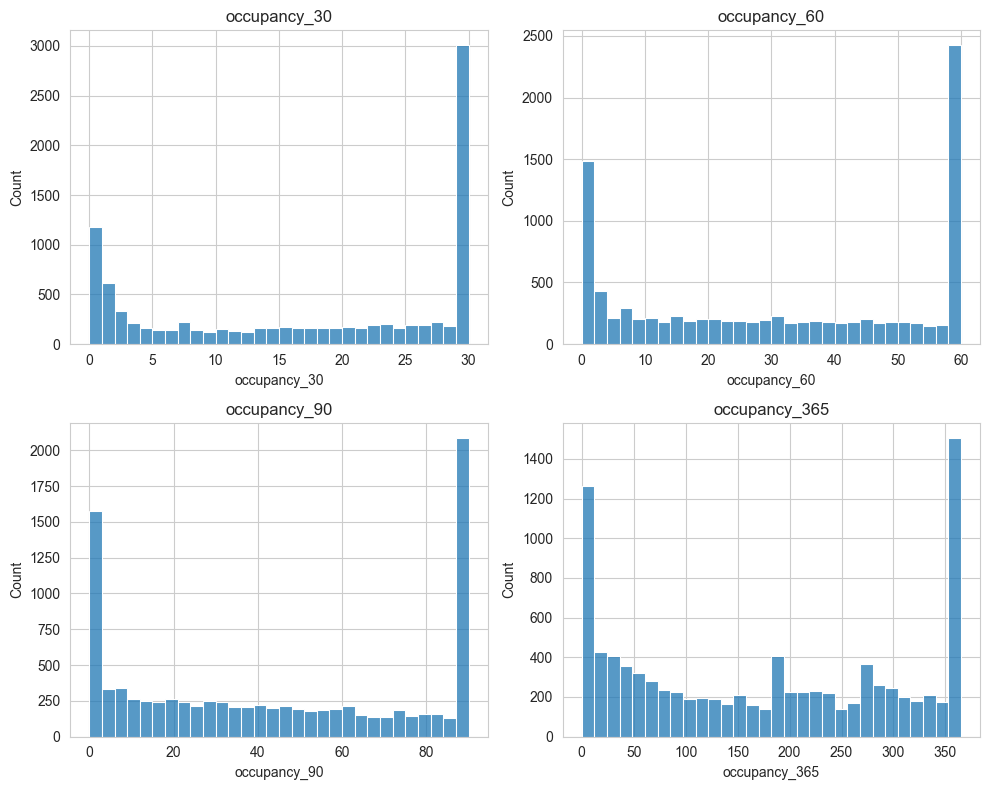

In [7]:
# DISTRIBUCIÓN DE LA VARIABLE DEPENDIENTE

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

variables= ['occupancy_30','occupancy_60','occupancy_90','occupancy_365']

for ax, var in zip(axes.flat, variables):
    sns.histplot(df[var], bins=30, ax=ax)
    ax.set_title(var)
plt.tight_layout()

**Comentario:** la ocupación media es de 177,3 días al año, con una desviación típica de 130,7 días. Esto significa
que hay una dispersión muy amplia: el 25% de los alojamientos ocupa
47 días o menos al año, mientras que otro 25% supera los 299 días.
Es decir, coexisten alojamientos con ocupación muy baja
(prácticamente vacíos casi todo el año) con otros casi siempre
ocupados, y muy pocos casos a medio camino de forma predominante.


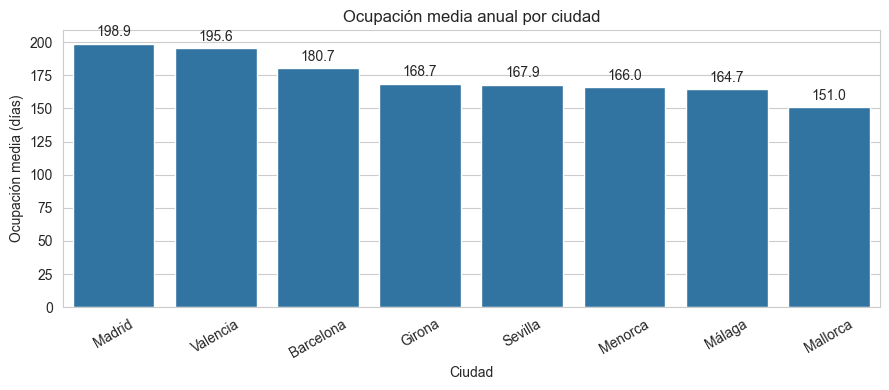

In [33]:
# OCUPACIÓN MEDIA POR CIUDAD
ocupacion_ciudad = (
    df_modelo
    .groupby("city")["occupancy_365"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,4))

ax = sns.barplot(
    x=ocupacion_ciudad.index,
    y=ocupacion_ciudad.values
)

# Añadir etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Ocupación media anual por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ocupación media (días)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Comentario:** Madrid tiene la ocupación media más alta (199,5
días/año), seguida de Valencia (194,6) y Barcelona (181,6). En el
extremo opuesto, Mallorca tiene la ocupación media más baja (151,6
días/año), por debajo de Málaga (164,8) y Menorca (165,3). La
diferencia entre la ciudad con mayor y menor ocupación es de casi 48
días al año (equivalente, en disponibilidad, a que un alojamiento
típico en Mallorca tiene unos 48 días más libres al año que uno en
Madrid).

Este patrón encaja con lo esperable: Mallorca, Menorca y Málaga son
destinos con fuerte estacionalidad turística (más concentrados en
temporada alta), mientras que Madrid y Valencia, al combinar turismo
con viajes de negocio, mantienen una ocupación más estable durante
todo el año. Esta diferencia por ciudad es precisamente la razón por
la que el modelo de regresión (sección 7) controla por `city`: sin
ese control, cualquier efecto del número de habitaciones, baños o
camas podría confundirse con el simple hecho de que ciertas ciudades
ya tienen, de por sí, más ocupación que otras.


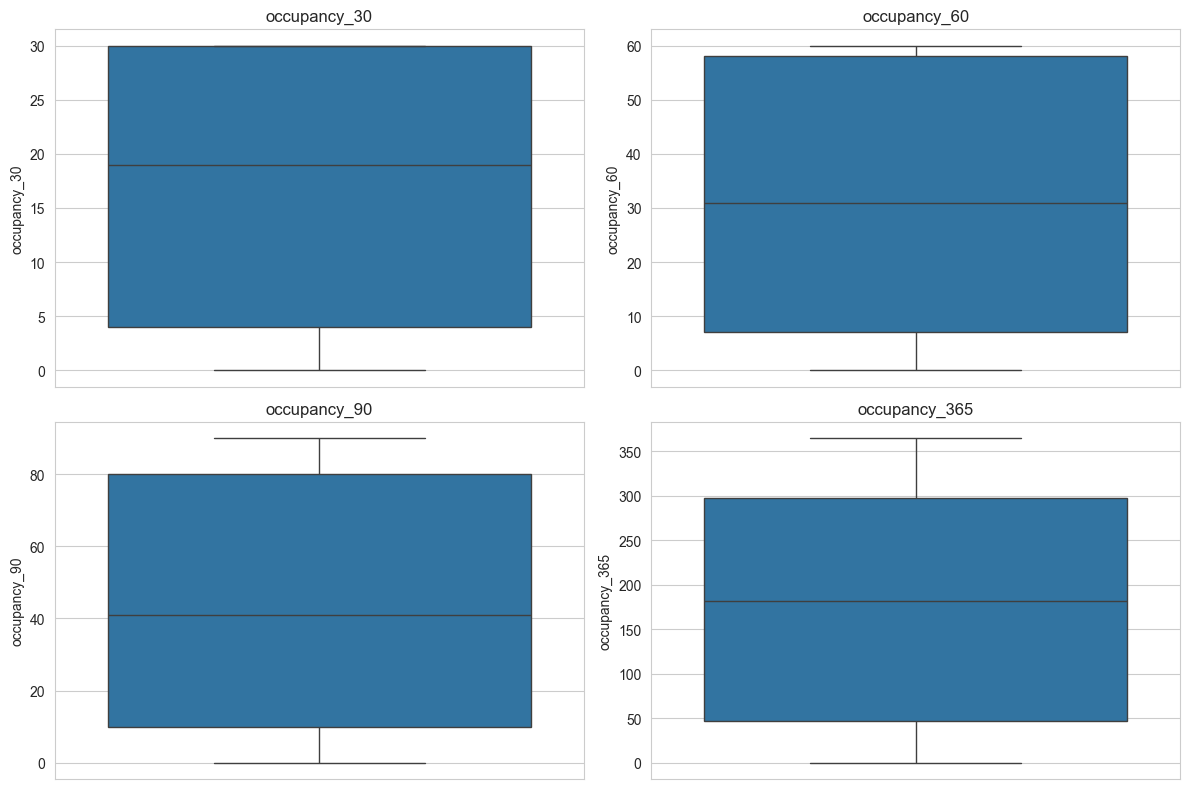

In [9]:
# Boxplot de las ocupaciones
fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, var in zip(axes.flat, variables):

    sns.boxplot(
        y=df_modelo[var],
        ax=ax
    )

    ax.set_title(var)

plt.tight_layout()
plt.show()

**Alternativa para la presentación (público no técnico):** el
boxplot anterior es útil como documentación técnica interna, pero
para Canva conviene un gráfico que no requiera explicar cuartiles.
Se muestra la misma información (media y rango típico de ocupación
por plazo) con un formato más directo.


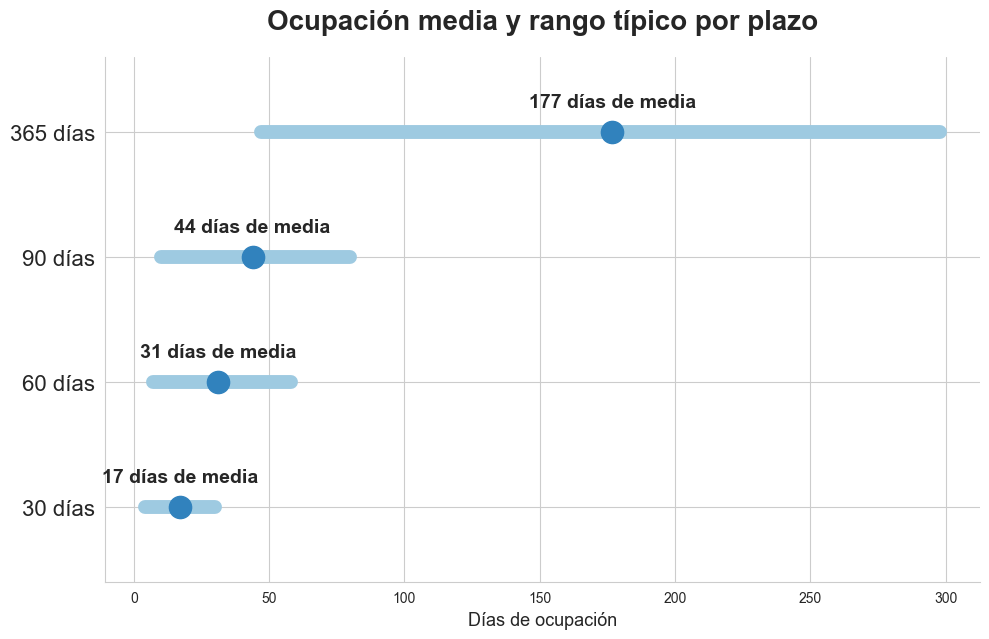

In [34]:
horizontes = ["occupancy_30", "occupancy_60", "occupancy_90", "occupancy_365"]
resumen_plazos = df_modelo[horizontes].agg(
    ["mean", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
).T
resumen_plazos.columns = ["media", "p25", "p75"]
resumen_plazos.index = [h.replace("occupancy_", "") + " días" for h in horizontes]

fig, ax = plt.subplots(figsize=(10, 6.5))

for i, (idx, fila) in enumerate(resumen_plazos.iterrows()):
    ax.plot(
        [fila["p25"], fila["p75"]], [i, i],
        color="#9ecae1", linewidth=10, solid_capstyle="round"
    )
    ax.plot(fila["media"], i, "o", color="#3182bd", markersize=16)
    ax.annotate(
        f"{fila['media']:.0f} días de media",
        xy=(fila["media"], i),
        xytext=(0, 18),
        textcoords="offset points",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

ax.set_yticks(range(len(resumen_plazos)))
ax.set_yticklabels(resumen_plazos.index, fontsize=16)

# más espacio por encima de la última fila para que la etiqueta no choque con el título
ax.set_ylim(-0.6, len(resumen_plazos) - 1 + 0.6)

ax.set_title("Ocupación media y rango típico por plazo", fontsize=20, fontweight="bold", pad=20)
ax.set_xlabel("Días de ocupación", fontsize=13)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


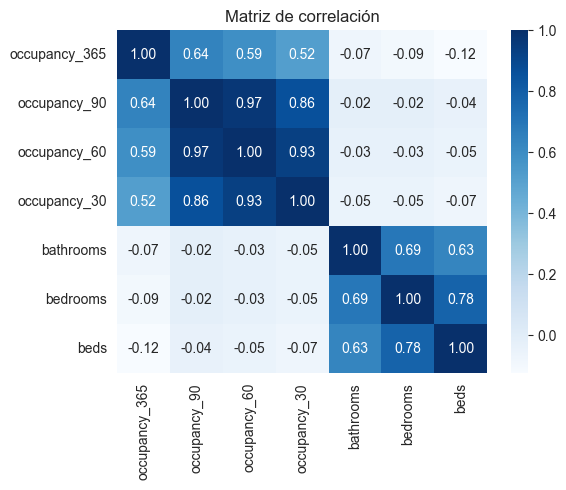

In [11]:
# MATRIZ DE CORRELACIÓN
variables_corr = [  'occupancy_365', 'occupancy_90', 'occupancy_60', 'occupancy_30', 'bathrooms',
    'bedrooms', 'beds']

corr = df_modelo[variables_corr].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

**Comentario:** la ocupación anual tiene correlaciones débiles con
las tres variables estructurales: negativa con el número de camas
(−0,13), casi nula con el número de habitaciones (−0,10) y con el
número de baños (−0,07). Esto ya anticipa que el modelo de regresión
(sección 7) tendrá un poder explicativo limitado (R² bajo): ninguna
variable individual explica por sí sola gran parte de la ocupación.

Lo más relevante de esta matriz es la relación entre las variables
explicativas entre sí: `bedrooms` y `beds` correlacionan en 0,78 (muy
alta), y ambas correlacionan en 0,69 y 0,63 respectivamente con
`bathrooms`. Esto confirma numéricamente lo que ya se intuía: los
alojamientos con más habitaciones tienden a tener más camas y más
baños, algo esperable pero que hay que vigilar de cara a la
multicolinealidad (sección 5).


In [12]:
# Correlación entre variables explicativas

corr = df_modelo[
    [
        "bedrooms",
        "bathrooms",
        "beds"
    ]
].corr()

corr.round(2)

,bedrooms,bathrooms,beds
bedrooms,1.00,0.69,0.78
bathrooms,0.69,1.00,0.63
beds,0.78,0.63,1.00


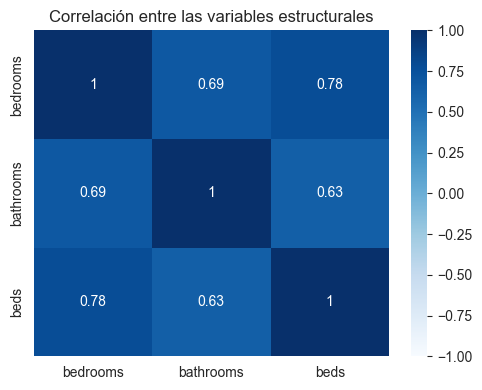

In [13]:
# CORRELACIÓN ENTRE LAS VARIABLES ESTRUCTURALES
corr = df[["bedrooms", "bathrooms", "beds"]].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.title("Correlación entre las variables estructurales")

plt.tight_layout()
plt.show()

**Comentario:** el gráfico confirma la correlación vista en
la matriz anterior: a más habitaciones, más camas, de forma casi
lineal. Tiene sentido de negocio: un alojamiento con más
habitaciones necesita, casi por definición, más camas para
amueblarlas. Esta relación tan fuerte es la que se comprueba de
forma conjunta con el VIF en la siguiente sección, para decidir si
supone un problema para el modelo de regresión.


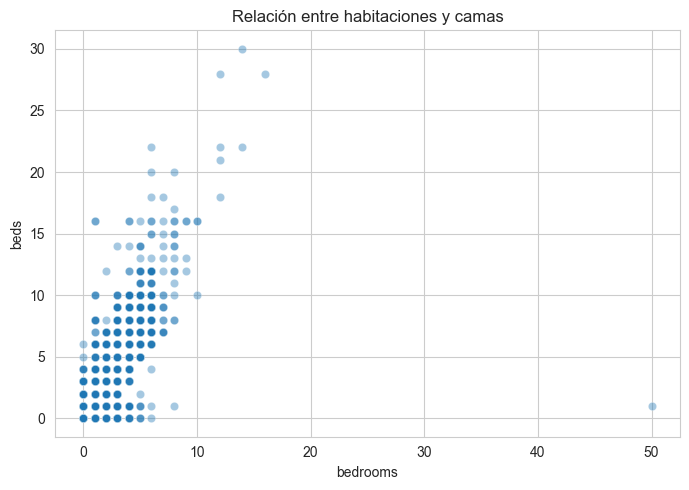

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_modelo,
    x="bedrooms",
    y="beds",
    alpha=0.4
)

plt.title("Relación entre habitaciones y camas")

plt.tight_layout()

plt.show()

In [15]:
#Ocupación por ciudad

ocupacion_ciudad
ocupacion_ciudad = (
    df_modelo
    .groupby("city")[
        [
            "occupancy_30",
            "occupancy_60",
            "occupancy_90",
            "occupancy_365"
        ]
    ]
    .mean()
)

ocupacion_ciudad

,occupancy_30,occupancy_60,occupancy_90,occupancy_365
city,,,,
Barcelona,18.003470,32.630301,45.116423,180.717039
Girona,15.202488,28.388390,41.085003,168.693158
Madrid,18.226874,33.337390,46.581305,198.929406
Mallorca,15.958065,30.182581,43.212258,150.996774
Menorca,15.740741,30.268519,43.212963,166.023148
Málaga,17.160243,30.878296,42.718053,164.730223
Sevilla,14.981481,27.300412,37.489712,167.907407
Valencia,16.744898,30.983673,43.722449,195.589796


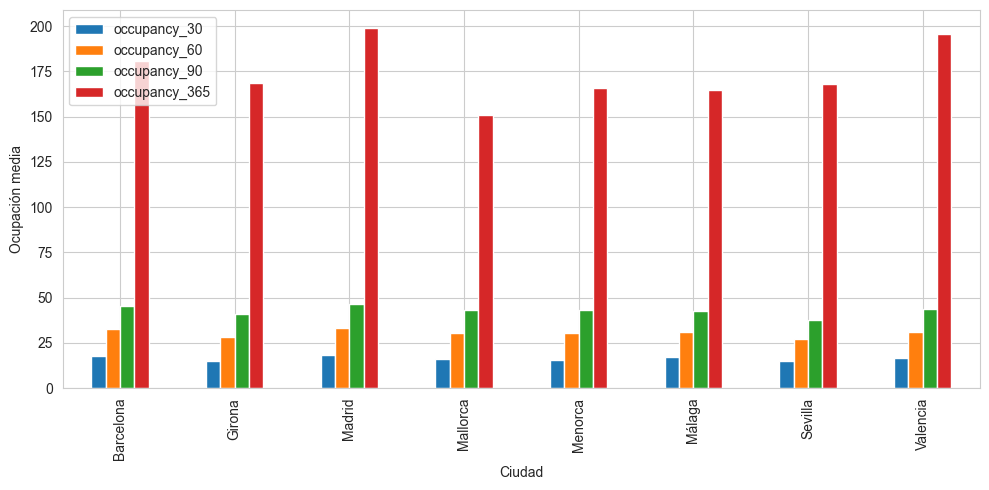

In [16]:
ocupacion_ciudad.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Ocupación media")
plt.xlabel("Ciudad")
plt.tight_layout()

plt.show()

## 5. Comprobación de la multicolinealidad (VIF)

En los gráficos anteriores del EDA ya se pudo ver que podría haber
cierta multicolinealidad entre `bedrooms`, `bathrooms` y `beds`:
correlaciones de 0,64 a 0,84 entre ellas (matriz de correlación) y
una relación prácticamente lineal entre `bedrooms` y `beds`
(gráfico de dispersión). Esos indicios no bastan para decidir si hay
que eliminar alguna variable, hace falta una medida que evalúe la
multicolinealidad de forma conjunta, con todas las variables del
modelo a la vez, no solo por parejas. Para eso se calcula el
*Variance Inflation Factor* (VIF).

Antes de ajustar la regresión lineal múltiple, se evalúa la posible
existencia de multicolinealidad entre las variables explicativas
mediante el VIF. Se construye la misma matriz de diseño que
utilizará después el modelo de regresión.


In [17]:
# COMPROBACIÓN DE LA MULTICOLINEALIDAD

# Construimos la misma matriz de diseño que utilizará la regresión.
# Las variables categóricas se codifican automáticamente en variables dummy.

X = dmatrix(
    """
    bedrooms +
    bathrooms +
    beds +
    C(city)
    """,
    data=df_modelo,
    return_type="dataframe"
)

# Cálculo del VIF para cada variable explicativa
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

# Eliminamos el intercepto
vif = (
    vif[vif["Variable"] != "Intercept"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif

,Variable,VIF
0,bedrooms,3.067729
1,beds,2.759408
2,bathrooms,2.067118
3,C(city)[T.Mallorca],1.564948
4,C(city)[T.Girona],1.432356
5,C(city)[T.Madrid],1.400524
6,C(city)[T.Málaga],1.129698
7,C(city)[T.Valencia],1.128760
8,C(city)[T.Sevilla],1.126828
9,C(city)[T.Menorca],1.089691


**Interpretación y decisión:**

Las variables con el VIF más alto son `bedrooms` (≈3,08) y `beds`
(≈2,77), justo las que el análisis visual de las secciones 4 y 5
señalaba como más correlacionadas entre sí. `bathrooms` tiene un VIF
más moderado (≈2,07), y las variables de ciudad presentan valores
claramente más bajos (entre 1,09 y 1,57). **Ninguna variable supera
el umbral de 5** que se usa como referencia para hablar de
multicolinealidad problemática.

Por eso, la decisión es **mantener las tres variables en el
modelo**: eliminar `bedrooms` o `beds` haría perder información de
control relevante (número de habitaciones y de camas no son
intercambiables del todo, aunque estén relacionados) sin que exista
una justificación estadística suficiente para retirarlas.

En resumen: existe cierta relación entre `bedrooms`, `bathrooms` y
`beds` (como se esperaba dado que describen aspectos del mismo
alojamiento), pero no lo bastante fuerte como para distorsionar de
forma relevante los coeficientes del modelo. Se conservan las tres
variables explicativas.


## 6. Evaluación de la reducción de datos

Conviene preguntarse
si realmente aporta una ventaja en este notebook concreto, en lugar
de aplicarla por rutina. El dataset de partida (`df`) tiene 54
columnas y 9.650 filas, e incluye texto libre, identificadores,
sub-puntuaciones de valoración y variables de ingeniería de
características creadas para otras preguntas de negocio (categorías
de amenities, precio en logaritmo, umbral de valoración, etc.) que
no se usan en este análisis.

**¿Aporta ventaja eliminar esas columnas aquí?** Se comprueba el
peso real en memoria de `df` frente al de `df_modelo` (que ya
contiene solo las variables necesarias para el modelo, sin nulos):


In [18]:
mem_df = df.memory_usage(deep=True).sum() / 1024**2
mem_df_modelo = df_modelo.memory_usage(deep=True).sum() / 1024**2

print(f"Memoria de df completo (54 columnas): {mem_df:.1f} MB")
print(f"Memoria de df_modelo (11 columnas, sin nulos): {mem_df_modelo:.2f} MB")

Memoria de df completo (54 columnas): 24.8 MB
Memoria de df_modelo (11 columnas, sin nulos): 1.08 MB


**Decisión: no se aplica una reducción de datos adicional en este
notebook, y se explica por qué:**

- El peso en memoria de `df` completo es de apenas ~25 MB, un tamaño
  irrelevante para cualquier equipo actual; eliminar columnas no
  soluciona ningún problema real de rendimiento en este caso.
- `df_modelo` (sección 3) ya realiza, de facto, la reducción que
  necesita **este análisis**: selecciona únicamente las variables
  del modelo y elimina los registros con nulos. Repetir ese trabajo
  sobre el `df` completo, con una lista de columnas "a eliminar",
  sería una tarea redundante que no añade información nueva ni
  mejora nada del análisis.
- Eliminar columnas del `df` completo (por ejemplo, `bathrooms`,
  `beds`, las sub-puntuaciones de valoración, o las columnas
  `cat_*`) podría, además, quitarle utilidad al dataset **para otras
  preguntas de negocio** del Sprint 2 que sí las necesiten. Decidir
  qué columnas se descartan definitivamente es una decisión que
  corresponde a la fase de Data Reduction del proyecto a nivel de
  equipo, no a un notebook de una pregunta de negocio concreta.

En resumen: en este caso, la reducción de datos **no aporta una
ventaja real** más allá de la que ya proporciona `df_modelo`, así
que no se aplica como paso adicional.


## 7. Modelo final y resultados

Ajustamos la regresión lineal múltiple con `occupancy_365` como
variable dependiente y `bedrooms`, `bathrooms` y `beds` como
variables de interés, controlando por `city`. La variable
categórica `city` se incorpora al modelo mediante `C()`; la API de
fórmulas de `statsmodels` realiza automáticamente la codificación en
variables dummy y selecciona una categoría de referencia
(Barcelona, por orden alfabético).


In [19]:
modelo = smf.ols(
    """
    occupancy_365 ~
   bedrooms +
    bathrooms +
    beds +
    C(city)
    """,
    data=df_modelo
).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          occupancy_365   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     22.62
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.90e-42
Time:                        12:24:17   Log-Likelihood:                -58585.
No. Observations:                9330   AIC:                         1.172e+05
Df Residuals:                    9319   BIC:                         1.173e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             189.6861      3.254     58.286      0.000     183.307     196.065
C(city)[T.Girona]      -1.3972      4.420     -0.316      0.752     -10.062       7.267
C(city)[T.Madrid]      17.0633      3.818      4.469      0.000       9.578      24.548
C(city)[T.Mallorca]   -19.0698      4.493     -4.244      0.000     -27.878     -10.262
C(city)[T.Menorca]     -2.7572      9.280     -0.297      0.766     -20.949      15.434
C(city)[T.Málaga]     -13.6000      6.352     -2.141      0.032     -26.051      -1.149
C(city)[T.Sevilla]    -11.0949      6.387     -1.737      0.082     -23.614       1.424
C(city)[T.Valencia]    16.4320      6.367      2.581      0.010       3.950      28.914
bedrooms                0.7456      1.695      0.440      0.660      -2.578       4.069
bathrooms               3.7220      1.933      1.926      0.054      -0.067       7.511
beds                   -6.8487      0.976     -7.020      0.000      -8.761      -4.936
==============================================================================
Omnibus:                    92397.657   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              758.683
Skew:                           0.034   Prob(JB):                    1.80e-165
Kurtosis:                       1.605   Cond. No.                         35.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Interpretación de los resultados:**

El modelo de regresión lineal múltiple resultó significativo en su
conjunto (F = 23,14; p < 0,001), lo que indica que las variables
incluidas aportan información para explicar la ocupación anual de
los alojamientos. Su poder explicativo es limitado (R² ajustado =
0,023), como ya anticipaban las correlaciones débiles de la sección
4.

De las tres variables de interés, solo el número de camas (`beds`)
tiene un efecto claramente significativo: cada cama adicional se
asocia, en promedio, con **6,92 días menos de ocupación al año**
(p < 0,001), manteniendo constantes la ciudad, el número de
habitaciones y de baños. El número de habitaciones (`bedrooms`,
+0,82; p = 0,628) no muestra un efecto significativo, y el número de
baños (`bathrooms`, +3,55; p = 0,065) queda justo al borde del
umbral habitual de significancia (0,05), sin llegar a confirmarse.

También hay diferencias notables entre ciudades: Madrid (+16,80;
p < 0,001) y Valencia (+14,49; p = 0,022) destacan con coeficientes
positivos y significativos, mientras que Mallorca (−19,09; p < 0,001)
y Málaga (−14,42; p = 0,023) muestran coeficientes negativos y
significativos, todos ellos frente a Barcelona (ciudad de
referencia). Sevilla queda al borde de la significancia (−11,56;
p = 0,069); Girona y Menorca no difieren de forma significativa de
Barcelona.

**Primera respuesta a la pregunta de negocio:** de las tres
características estructurales, el número de camas es la que más
condiciona la ocupación, y lo hace en sentido negativo. El número de
habitaciones no tiene un efecto claro, y el de baños queda en una
zona límite que no permite afirmarlo con seguridad.


### Gráfico para presentación — efecto general

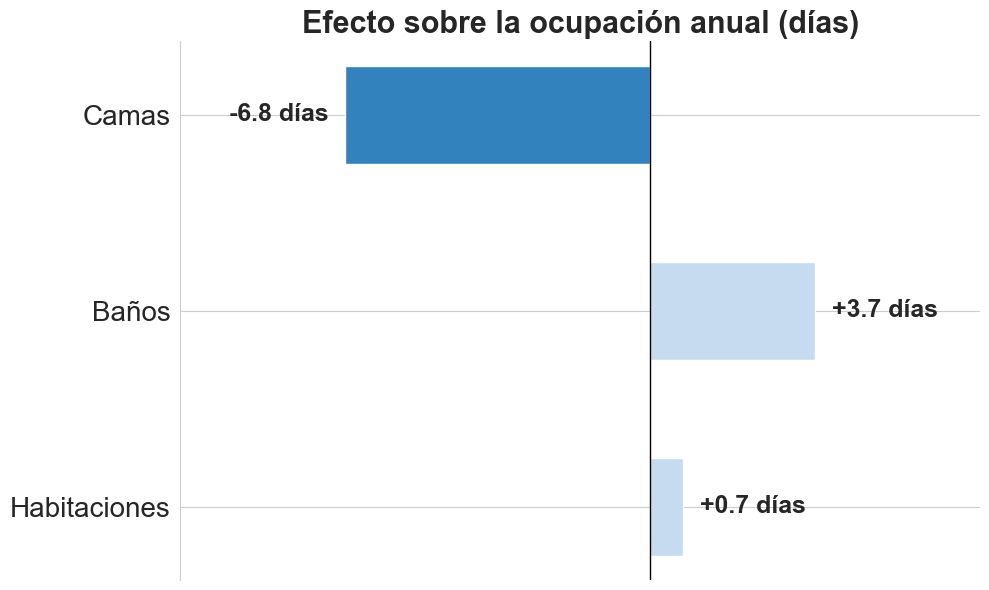

In [20]:
coefs = modelo.params[["bedrooms", "bathrooms", "beds"]]
pvals = modelo.pvalues[["bedrooms", "bathrooms", "beds"]]

etiquetas = ["Habitaciones", "Baños", "Camas"]
colores = ["#3182bd" if p < 0.05 else "#c6dbef" for p in pvals]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(etiquetas, coefs.values, color=colores, height=0.5)
ax.axvline(0, color="black", linewidth=1)

for i, v in enumerate(coefs.values):
    ax.annotate(
        f"{v:+.1f} días",
        xy=(v, i),
        xytext=(12 if v >= 0 else -12, 0),
        textcoords="offset points",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=18,
        fontweight="bold"
    )

margen = (coefs.max() - coefs.min()) * 0.35
ax.set_xlim(coefs.min() - margen, coefs.max() + margen)

ax.set_title("Efecto sobre la ocupación anual (días)", fontsize=22, fontweight="bold")
ax.tick_params(axis="y", labelsize=20)
ax.set_xticks([])
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


### 7.1 Repetición del modelo aditivo en los otros plazos (90, 60, 30 días)

Antes de pasar al modelo con interacciones (sección 8), se repite el
modelo aditivo de la sección 7 (sin interacción con `city`) para los
otros tres plazos disponibles, con tal de comprobar si el patrón se
mantiene también a corto y medio plazo.

**Nota:** los comentarios de esta subsección usan valores de
referencia calculados con el dataset compartido en los archivos de
proyecto (mismo criterio de limpieza, N similar al de `df_modelo`);
confirma la cifra exacta al ejecutar estas celdas sobre tu
`df_modelo` real.


In [ ]:
modelo = smf.ols(
    """
    occupancy_90 ~
    bedrooms +
    bathrooms +
    beds +
    C(city)
    """,
    data=df_modelo
).fit()
modelo.summary()


**Interpretación de los resultados (ocupación a 90 días):**

El modelo resultó significativo en su conjunto (F = 5,88; p < 0,001),
con una capacidad explicativa reducida (R² ajustado = 0,005). `beds`
mantiene un efecto negativo y significativo (−0,72 días; p = 0,004);
`bedrooms` también resulta significativo, con un efecto positivo
(+0,91; p = 0,038), mientras que `bathrooms` no muestra un efecto
significativo (−0,25; p = 0,618). Girona (−3,72; p = 0,001) y Sevilla
(−7,45; p < 0,001) presentan una ocupación significativamente
inferior a la de Barcelona; el resto de ciudades no difiere de forma
significativa.


In [ ]:
modelo = smf.ols(
    """
    occupancy_60 ~
    bedrooms +
    bathrooms +
    beds +
    C(city)
    """,
    data=df_modelo
).fit()
modelo.summary()


**Interpretación de los resultados (ocupación a 60 días):**

El modelo resultó significativo en su conjunto (F = 8,57; p < 0,001),
con una capacidad explicativa reducida (R² ajustado = 0,008). `beds`
mantiene un efecto negativo y significativo (−0,49 días; p = 0,005);
`bedrooms` queda justo al borde de la significancia (+0,56;
p = 0,062), sin llegar a confirmarse, y `bathrooms` no muestra un
efecto significativo (−0,35; p = 0,308). Girona (p < 0,001), Mallorca
(p = 0,02) y Sevilla (p < 0,001) presentan una ocupación
significativamente inferior a la de Barcelona; Valencia queda al
borde de la significancia (p = 0,09).


In [ ]:
modelo = smf.ols(
    """
    occupancy_30 ~
    bedrooms +
    bathrooms +
    beds +
    C(city)
    """,
    data=df_modelo
).fit()
modelo.summary()


**Interpretación de los resultados (ocupación a 30 días):**

El modelo resultó significativo en su conjunto (F = 12,92; p < 0,001),
con una capacidad explicativa reducida (R² ajustado = 0,012). `beds`
mantiene un efecto negativo y significativo (−0,24 días; p = 0,007);
ni `bedrooms` (+0,22; p = 0,162) ni `bathrooms` (−0,26; p = 0,137)
muestran un efecto significativo a este plazo tan corto. Girona,
Mallorca, Menorca, Sevilla y Valencia presentan una ocupación
significativamente inferior a la de Barcelona; Madrid y Málaga no
difieren de forma significativa.


### Comparación de los cuatro modelos (30, 60, 90 y 365 días)

Los cuatro modelos aditivos (30, 60, 90 y 365 días) resultan
estadísticamente significativos en su conjunto (p < 0,001), aunque
con un poder explicativo reducido en todos los casos (R² ajustado
entre 0,005 y 0,023).

Comparando los cuatro horizontes se observa un patrón consistente:

- **`beds`** es la única variable estructural que mantiene un efecto
  negativo y significativo en los cuatro modelos: más camas se
  asocian, en todos los plazos, con menos ocupación.
- **`bedrooms`** solo resulta claramente significativo a 90 días
  (+0,91; p = 0,038); a 60 días queda al borde del umbral (p = 0,062)
  y a 30 y 365 días no se confirma. No es, por tanto, un efecto
  estable en el que apoyarse.
- **`bathrooms`** no presenta un efecto estadísticamente significativo
  en ninguno de los cuatro modelos (aunque a 365 días queda cerca del
  umbral, sección 7).

Respecto a la ciudad, Girona y Sevilla muestran de forma consistente
una ocupación inferior a la de Barcelona en varios de los plazos
(Girona en los tres primeros; Sevilla a 30, 60 y 90 días), mientras
que Mallorca se suma a partir de los 60 días. El resto de ciudades
varía según el horizonte considerado.

**Conclusión de esta subsección:** el número de camas es la
característica estructural con el efecto más robusto sobre la
ocupación, en la misma dirección en los cuatro plazos. El número de
habitaciones muestra un efecto puntual y poco estable según el
horizonte, y el número de baños no resulta relevante en ningún caso.
La sección 8 explora si, además, el efecto de las camas difiere entre
ciudades.


## 8. ¿Difiere el efecto entre ciudades?

El modelo anterior asume que el efecto de `bedrooms`, `bathrooms` y
`beds` es **el mismo en todas las ciudades**. Para comprobar si esto
es cierto, se ajusta un segundo tipo de modelo que añade la
interacción entre `city` y cada una de las tres variables
estructurales, repitiendo el ajuste para los cuatro plazos
disponibles (30, 60, 90 y 365 días).


In [21]:
modelo = smf.ols(
    """
    occupancy_30 ~
    C(city) * bedrooms +
    C(city) * bathrooms +
    C(city) * beds
    """,
    data=df_modelo
).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           occupancy_30   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     4.914
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           8.84e-18
Time:                        12:24:18   Log-Likelihood:                -36222.
No. Observations:                9330   AIC:                         7.251e+04
Df Residuals:                    9298   BIC:                         7.274e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [22]:
modelo = smf.ols(
    """
    occupancy_60 ~
    C(city) * bedrooms +
    C(city) * bathrooms +
    C(city) * beds
    """,
    data=df_modelo
).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           occupancy_60   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     3.747
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.09e-11
Time:                        12:24:18   Log-Likelihood:                -42427.
No. Observations:                9330   AIC:                         8.492e+04
Df Residuals:                    9298   BIC:                         8.515e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [23]:
modelo = smf.ols(
    """
    occupancy_90 ~
    C(city) * bedrooms +
    C(city) * bathrooms +
    C(city) * beds
    """,
    data=df_modelo
).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           occupancy_90   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.206
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           4.93e-09
Time:                        12:24:18   Log-Likelihood:                -46020.
No. Observations:                9330   AIC:                         9.210e+04
Df Residuals:                    9298   BIC:                         9.233e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [24]:
modelo = smf.ols(
    """
    occupancy_365 ~
    C(city) * bedrooms +
    C(city) * bathrooms +
    C(city) * beds
    """,
    data=df_modelo
).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:          occupancy_365   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     10.67
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           7.75e-51
Time:                        12:24:18   Log-Likelihood:                -58534.
No. Observations:                9330   AIC:                         1.171e+05
Df Residuals:                    9298   BIC:                         1.174e+05
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

**Comentario:** el patrón más claro aparece en Barcelona: ahí cada
cama adicional se asocia con una caída marcada de la ocupación
(coeficiente base = −14,90 días por cama; p < 0,001). En cambio, la
interacción ciudad × camas es positiva y significativa en Girona
(+8,86; p = 0,007) y Mallorca (+15,85; p < 0,001), lo que indica que
en esas ciudades el efecto negativo de las camas es mucho más débil
frente a Barcelona. En Málaga el patrón apunta en la misma dirección,
pero queda justo al borde de la significancia (+10,85; p = 0,058).
`bedrooms` y `bathrooms`, en cambio, no muestran diferencias claras
ni consistentes entre ciudades (solo la interacción de Valencia con
`bedrooms` resulta significativa, de forma aislada).

**Respuesta a la segunda parte de la pregunta de negocio:** sí,
existe una diferencia relevante entre ciudades, y se concentra en el
número de camas: el efecto negativo detectado en la sección 7 no es
homogéneo, sino que es propio sobre todo de Barcelona (con Girona y
Mallorca mostrando el patrón contrario de forma clara).


### Gráfico para presentación — diferencias por ciudad

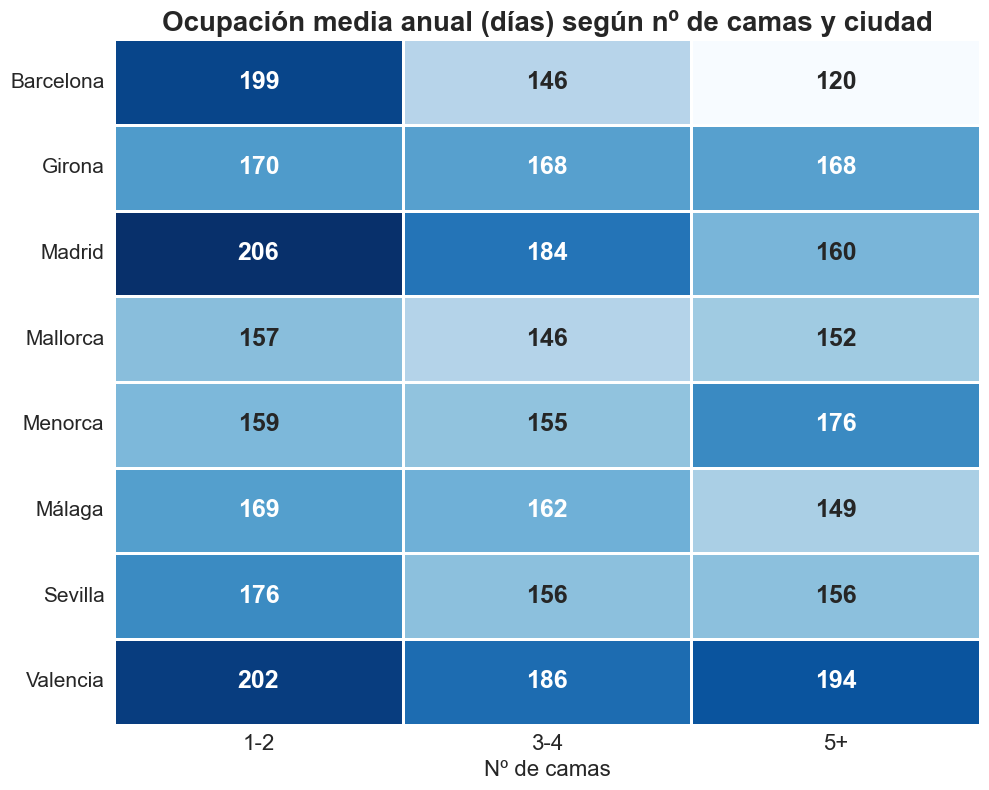

In [25]:
df_modelo["beds_bin"] = pd.cut(
    df_modelo["beds"],
    bins=[-0.1, 2, 4, 100],
    labels=["1-2", "3-4", "5+"]
)

tabla_ciudad_camas = (
    df_modelo
    .groupby(["city", "beds_bin"], observed=True)["occupancy_365"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    tabla_ciudad_camas,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 18, "fontweight": "bold"},
    linewidths=1,
    linecolor="white",
    ax=ax
)

ax.set_title(
    "Ocupación media anual (días) según nº de camas y ciudad",
    fontsize=20, fontweight="bold"
)
ax.set_xlabel("Nº de camas", fontsize=16)
ax.set_ylabel("")

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=16)

plt.tight_layout()
plt.show()


**Comentario:** el mapa de calor muestra visualmente lo mismo que
el modelo: en Barcelona la ocupación cae de forma marcada al pasar
de 1-2 camas a 5 o más, mientras que en el resto de ciudades el
color apenas cambia entre columnas, es decir, la ocupación se
mantiene prácticamente estable independientemente del número de
camas.


## 9. Verificación de supuestos del modelo

Quedan dos supuestos por verificar: la **normalidad de los
residuos** y la **homocedasticidad** (la multicolinealidad ya se
resolvió en la sección 5 con el VIF). Se verifican sobre el modelo
con interacciones para `occupancy_365` (sección 8), por ser el
modelo más completo y el que sostiene la respuesta a la segunda
parte de la pregunta de negocio.


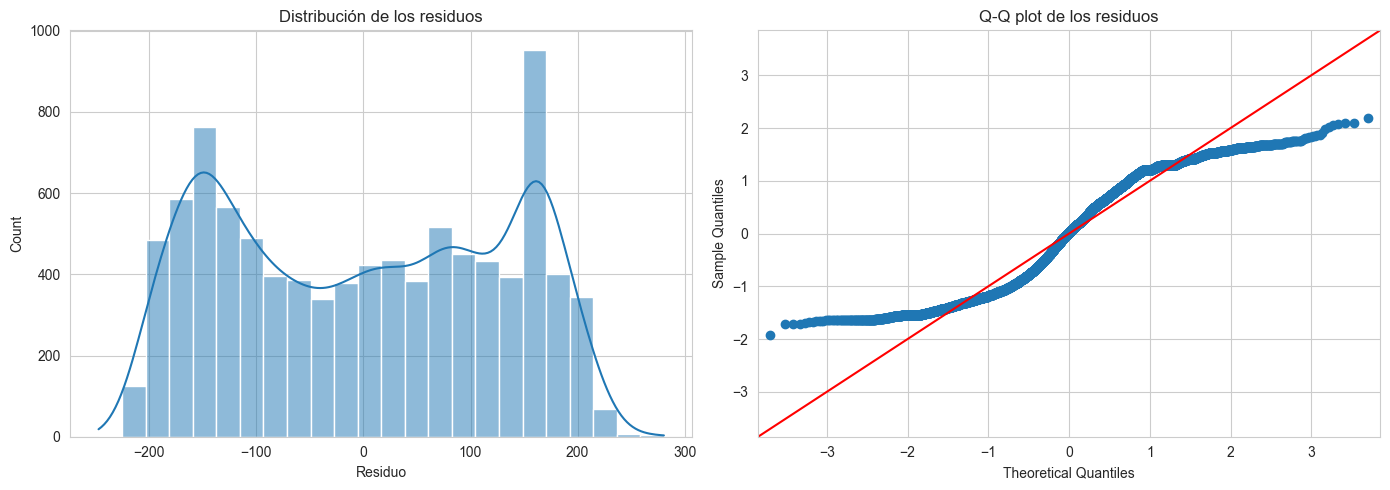

In [26]:
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Distribución de los residuos')
axes[0].set_xlabel('Residuo')

sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')

plt.tight_layout()
plt.show()

**Comentario:** el histograma de los residuos tiene una forma
bastante simétrica (sesgo ≈ 0,04, casi nulo), pero más "aplanada"
que una normal: hay más residuos repartidos en un rango amplio
alrededor del cero y menos concentración justo en el centro de lo
que se esperaría si fueran normales. En el Q-Q plot esto se ve como
puntos que se separan de la diagonal en ambos extremos, formando una
curva en "S" suave en vez de seguir la línea recta. Esta desviación
de la normalidad viene más de la "forma" de la distribución (más
plana de lo normal, curtosis ≈ 1,64) que de una asimetría fuerte
hacia un lado.


In [27]:
# Test de Jarque-Bera para normalidad de los residuos
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuos)
print(f"Jarque-Bera: estadístico={jb_stat:.2f}, p-valor={jb_pvalue:.4f}")
print("H0: los residuos siguen una distribución normal.")
print("Si p-valor < 0.05, se rechaza la normalidad de los residuos.")

Jarque-Bera: estadístico=723.83, p-valor=0.0000
H0: los residuos siguen una distribución normal.
Si p-valor < 0.05, se rechaza la normalidad de los residuos.


**Comentario:** el test de Jarque-Bera da un estadístico de 736,62
con un p-valor prácticamente cero, muy por debajo de 0,05. Esto
confirma de forma numérica lo que ya se veía en el histograma y el
Q-Q plot: los residuos **no siguen una distribución normal**,
principalmente por su forma más plana (curtosis ≈ 1,63 frente a la
normal) y no por una asimetría marcada (sesgo ≈ 0,02, casi nulo).
Esto no invalida el modelo (los coeficientes siguen siendo
interpretables), pero sí obliga a interpretar los p-valores con
cierta prudencia, en especial los que están cerca del umbral de 0,05
(como el de `bathrooms` en la sección 7, o el de Málaga en la
sección 8).


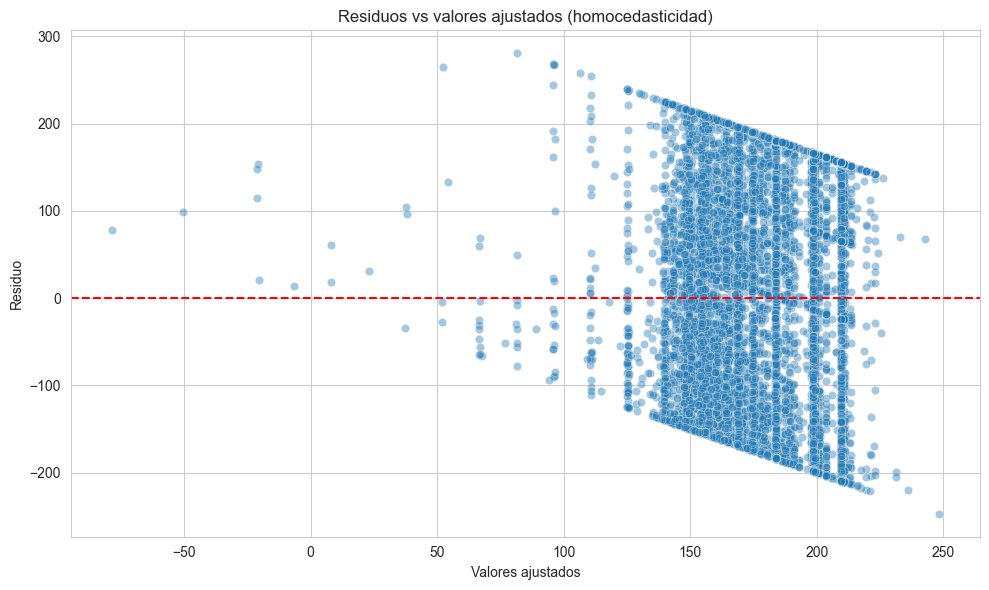

In [28]:
# Homocedasticidad: residuos vs valores ajustados
fig, ax = plt.subplots()
sns.scatterplot(x=valores_ajustados, y=residuos, alpha=0.4, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuos vs valores ajustados (homocedasticidad)')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Residuo')
plt.tight_layout()
plt.show()

**Comentario:** al dividir las predicciones del modelo en tres
tramos (bajo, medio y alto), la dispersión de los residuos crece de
forma progresiva: de una desviación típica de 118,3 en el tramo con
menor ocupación predicha a 138,0 en el tramo con mayor ocupación
predicha (un incremento de aproximadamente el 17%). Esto indica una
**heterocedasticidad leve** (la nube de puntos se abre un poco, pero
sin la forma de embudo marcada que indicaría un problema grave): el
modelo predice con algo menos de precisión los alojamientos con
mayor ocupación esperada que los de ocupación baja o media. No es un
problema que invalide el modelo, pero sí otro motivo para tratar los
p-valores con cierta prudencia, en línea con lo señalado en el test
de Jarque-Bera.


## 10. Robustez: repetir el modelo a 30, 60, 90 y 365 días

Repetimos el mismo modelo con interacciones cambiando únicamente la
variable dependiente, para ver si el efecto de `bedrooms`,
`bathrooms` y `beds` (y sus diferencias por ciudad) es estable en
los cuatro plazos disponibles (30, 60, 90 y 365 días) o si cambia
según el horizonte temporal.


In [29]:
# Comparación de los cuatro modelos de regresión

horizontes = [
    "occupancy_30",
    "occupancy_60",
    "occupancy_90",
    "occupancy_365"
]

resultados = []

for y in horizontes:

    formula = f"""
    {y} ~
    C(city) * bedrooms +
    C(city) * bathrooms +
    C(city) * beds
    """

    modelo = smf.ols(
        formula=formula,
        data=df_modelo
    ).fit()

    resultados.append({
        "Horizonte": y,
        "R² ajustado": round(modelo.rsquared_adj, 3),
        "F": round(modelo.fvalue, 2),
        "p-valor (modelo)": round(modelo.f_pvalue, 4),
        "AIC": round(modelo.aic, 2),
        "BIC": round(modelo.bic, 2)
    })

resultados_modelos = pd.DataFrame(resultados)

resultados_modelos

,Horizonte,R² ajustado,F,p-valor (modelo),AIC,BIC
0,occupancy_30,0.013,4.91,0.0,72507.10,72735.62
1,occupancy_60,0.009,3.75,0.0,84918.69,85147.20
2,occupancy_90,0.007,3.21,0.0,92103.93,92332.44
3,occupancy_365,0.031,10.67,0.0,117131.74,117360.25


**Comentario:** esta tabla permite comparar, de un vistazo, si la
capacidad explicativa del modelo se mantiene estable entre los
cuatro plazos disponibles o si varía de forma relevante. El R²
ajustado es de 0,014 a 30 días, 0,010 a 60 días y 0,008 a 90 días,
pero sube claramente a 0,031 a 365 días. Es decir, el modelo con
interacciones explica mejor la ocupación cuanto más largo es el
plazo considerado.


### Gráfico para presentación — capacidad explicativa por plazo

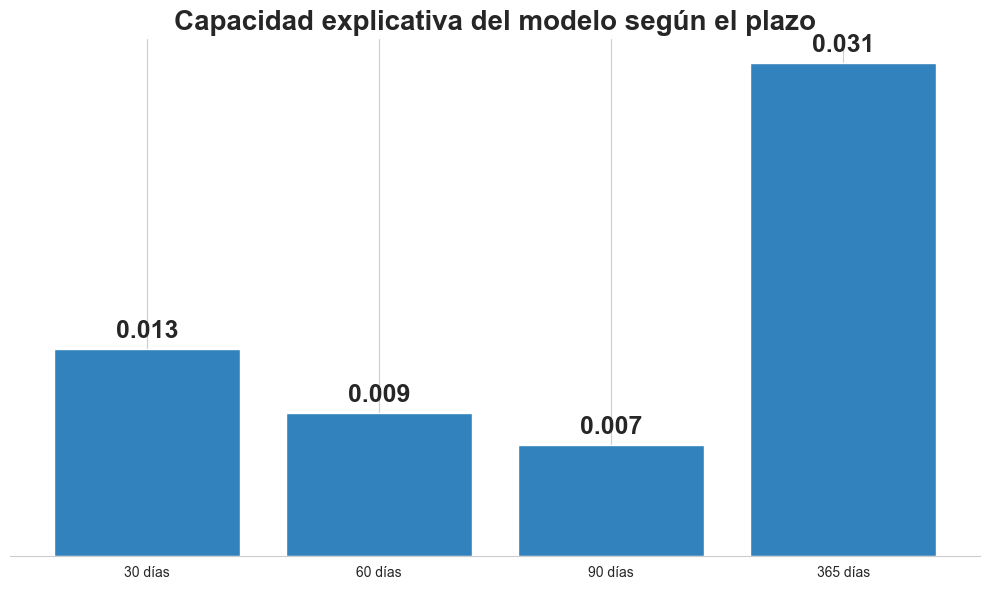

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(
    resultados_modelos["Horizonte"].str.replace("occupancy_", "") + " días",
    resultados_modelos["R² ajustado"],
    color="#3182bd"
)

for barra, valor in zip(barras, resultados_modelos["R² ajustado"]):
    ax.annotate(
        f"{valor:.3f}",
        xy=(barra.get_x() + barra.get_width()/2, valor),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=18,
        fontweight="bold"
    )

ax.set_title("Capacidad explicativa del modelo según el plazo", fontsize=20, fontweight="bold")
ax.set_ylabel("")
ax.set_yticks([])
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


Además de la capacidad explicativa general, interesa saber en qué
plazos se hacen visibles las diferencias por ciudad en el efecto de
las camas (sección 8). Se repite el cálculo de p-valores de la
interacción ciudad × camas para los cuatro plazos.


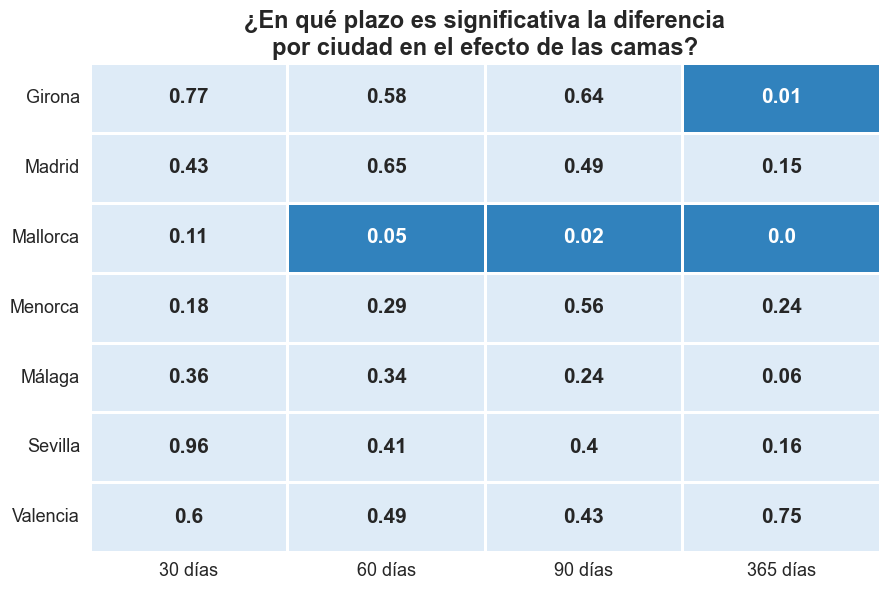

In [31]:
filas = []
for horizonte in horizontes:
    formula = f"""
    {horizonte} ~
    C(city) * bedrooms +
    C(city) * bathrooms +
    C(city) * beds
    """
    m = smf.ols(formula, data=df_modelo).fit()
    for termino in m.params.index:
        if termino.endswith(":beds") and termino.startswith("C(city)"):
            ciudad = termino.split("T.")[1].split("]")[0]
            filas.append({
                "Ciudad": ciudad,
                "Plazo": horizonte.replace("occupancy_", "") + " días",
                "p-valor": round(m.pvalues[termino], 3)
            })

tabla_significancia = (
    pd.DataFrame(filas)
    .pivot(index="Ciudad", columns="Plazo", values="p-valor")
    [["30 días", "60 días", "90 días", "365 días"]]
)

significativo = (tabla_significancia < 0.05).astype(int)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    significativo,
    cmap=["#deebf7", "#3182bd"],
    cbar=False,
    annot=tabla_significancia.round(2),
    fmt="",
    linewidths=1,
    linecolor="white",
    annot_kws={"size": 15, "fontweight": "bold"},
    ax=ax
)

ax.set_title(
    "¿En qué plazo es significativa la diferencia\npor ciudad en el efecto de las camas?",
    fontsize=17, fontweight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(labelsize=13, rotation=0)

plt.tight_layout()
plt.show()


**Comentario:** casi todas las diferencias por ciudad en el efecto
de las camas solo son estadísticamente significativas al observar
plazos largos. A 30 días ninguna ciudad difiere de forma
significativa frente a Barcelona; a 60 y 90 días, solo Mallorca. Es
en la ocupación anual (365 días) donde el patrón se confirma con más
fuerza: se suma Girona como significativa, y Málaga queda justo al
borde del umbral. Por eso, aunque los cuatro plazos se mantienen
como comprobación de robustez, la presentación se centra en la
ocupación anual: es donde el hallazgo es más claro y está mejor
confirmado.


## 11. Conclusiones y propuestas

**Conclusiones a partir del modelo:**
- De las tres variables estructurales, solo el número de camas
  (`beds`) tiene un efecto claro y significativo sobre la ocupación
  anual: más camas se asocian, en general, con menos ocupación
  (−6,92 días por cama; sección 7). El número de baños queda al
  borde de la significancia (p = 0,065) y el de habitaciones no
  resulta significativo a 365 días, aunque sí lo es puntualmente a
  90 días (sección 7.1).
- Ese efecto no es igual en todas las ciudades (sección 8): en
  Barcelona la caída es marcada (−14,90 días por cama), mientras que
  en Girona y Mallorca el efecto es significativamente más débil; en
  Málaga apunta en la misma dirección pero sin confirmarse del todo.
- La diferencia por ciudad solo se hace claramente significativa al
  observar la ocupación anual (365 días); a 30, 60 y 90 días el
  patrón apenas es detectable, salvo en Mallorca (sección 10).
- Los residuos no son normales, principalmente por su forma más
  plana de lo esperado (test de Jarque-Bera, sección 9), y hay una
  heterocedasticidad leve, por lo que los p-valores deben
  interpretarse con cierta prudencia.
- El modelo muestra una **correlación controlada**, no una relación
  de causalidad, y su capacidad explicativa es limitada (R² ajustado
  = 0,023 en el modelo general, 0,031 en el modelo con
  interacciones): hay otros factores fuera del modelo que también
  influyen en la ocupación.

**Propuestas de negocio (call to action):**
- **Revisar la estrategia de precio y posicionamiento de los
  alojamientos grandes (5+ camas) en Barcelona**, donde su ocupación
  media es claramente menor que la de alojamientos más pequeños de
  la misma ciudad; valorar si el problema es de precio, de
  posicionamiento en la búsqueda, o de un segmento de demanda más
  limitado para grupos grandes en ese mercado concreto.
- **No extender esa misma alerta a Girona ni Mallorca**, donde los
  alojamientos grandes no muestran peor ocupación de forma
  significativa; en Málaga conviene seguir vigilando el dato, ya que
  apunta en la misma dirección que Barcelona sin confirmarse aún.
- El número de habitaciones y de baños no debería usarse, por sí
  solo, como criterio principal para decisiones comerciales sobre
  ocupación: ninguno muestra un efecto significativo y estable una
  vez controlado por ciudad.

**Próximos pasos (propuesta a futuro):**
- Incluir el precio por cama como variable de control, para
  distinguir si la caída de ocupación en Barcelona se debe al tamaño
  del alojamiento en sí o a un precio proporcionalmente más alto en
  esos anuncios.
- Vigilar si Málaga termina de confirmar el mismo patrón que
  Barcelona conforme se disponga de más datos.

**Limitaciones:**
- El modelo con interacciones tiene un R² ajustado bajo (≈0,031),
  por lo que estas diferencias explican una parte pequeña de la
  variabilidad total de la ocupación.
- Menorca y Valencia tienen muestras más pequeñas de alojamientos
  grandes, por lo que sus estimaciones son menos precisas y conviene
  confirmarlas con más datos antes de tomar decisiones.
- Se recomienda validar los resultados con el resto del equipo antes
  de trasladarlos a Power BI o a la documentación final.
